# DarkNESS ALP concept of operations — the pictures

Six figures for intuition: how a geomagnetic ALP search is done from a
spacecraft, and what the DarkNESS ConOps has to get right. Every picture is
drawn from the simulated mission (`main_sequence.ipynb`, same settings); the
figure code is in `scripts/conops_figures.py` so the deck can reuse it.

1. **The conversion path** — the signal is a line integral of $\mathbf B_\perp$
   along the line of sight, through the field, until the Earth or empty space.
2. **What the aperture sees** — a 20° cone, and how much $K$ changes across it.
3. **One orbit** — $K$, the particle-background proxy and the limb angle rise
   and fall together: the identifiability problem.
4. **The ground track** — where science happens in a day, the modes, the
   weak-field region.
5. **Where to point** — every fixed sky direction held for a day, for the
   continuum, the Milky Way line, and the confound.
6. **What it buys** — expected counts for the allowed benchmark, and the
   mass reach from the phase-aware integral.

In [1]:
import sys; sys.path.append("../scripts")
import numpy as np
import matplotlib.pyplot as plt
from darknessalp import orbit, pointing, kinematics, sim, frames, field, geometry
from darknessalp.constants import R_EQUATOR_KM
from fov_view import fov_view
import conops_figures as cf

EPOCH = "2027-05-01T00:00:00"     # UTC
ALT_KM, INC_DEG = 420.0, 51.6      # ISS-like
ELEMENTS = dict(a_km=R_EQUATOR_KM + ALT_KM, e=0.0, inc_deg=INC_DEG,
                raan_deg=0.0, argp_deg=0.0, nu_deg=0.0)   # CCSDS OPM, GCRF
GRAVITY = "j2"
CADENCE_S, DURATION_S = 60.0, 86400.0
LMAX = 13
SLEW_DEG_S = 1.5                   # ASSUME
SCIENCE = pointing.mode("gc", roll="anti_earth")
SUNLIT = pointing.mode("anti_sun", roll="anti_earth")
RULES = [("umbra", SCIENCE), ("always", SUNLIT)]

## The mission, simulated

The main sequence in one cell: orbit, schedule, steering, state table.

In [2]:
t = np.arange(0.0, DURATION_S, CADENCE_S)
time = frames.times(EPOCH, t)
r0, v0 = orbit.elements_to_state(**ELEMENTS)
r, v = orbit.propagate(r0, v0, t, gravity=GRAVITY)
mode_index, modes = pointing.select(RULES, pointing.conditions(time, r))
desired = pointing.attitudes(modes, mode_index, time, r, v)
attitude, _, slewing = kinematics.steer(desired, t, SLEW_DEG_S, mode_index=mode_index)
n = kinematics.boresight(attitude)
table = sim.state_table(EPOCH, t, r, n, lmax=LMAX)
coeffs = field.load_igrf(float(np.mean(frames.decimal_year(time))))
sci = cf.science_mask(table, mode_index) & ~slewing
k0 = int(np.flatnonzero(sci)[np.argmax(table["k_fov_t2m2"][sci])])   # strongest science sample
print(f"{len(t)} samples; science exposure {sci.sum() * CADENCE_S / 3600:.1f} h; "
      f"strongest science sample at {t[k0] / 3600:.2f} h, K = {table['k_fov_t2m2'][k0]:.0f} T² m²")

1440 samples; science exposure 8.5 h; strongest science sample at 16.18 h, K = 65694 T² m²


## 1. The conversion path

An ALP arriving along the boresight converts to an X-ray photon in the part of
the geomagnetic field it crosses on the way to the detector. Only the field
component **perpendicular** to the ray counts, and the contributions add as an
amplitude: $A = \int \mathbf B_\perp\,e^{iqs}\,ds$, $K = |A|^2$. The ray runs
from the spacecraft outward until it leaves the field region or hits the
Earth — an occulted ray still converts along its short path. The right panel
is how $|A|$ builds up along the ray at the moment of the day when $K$ is
largest.

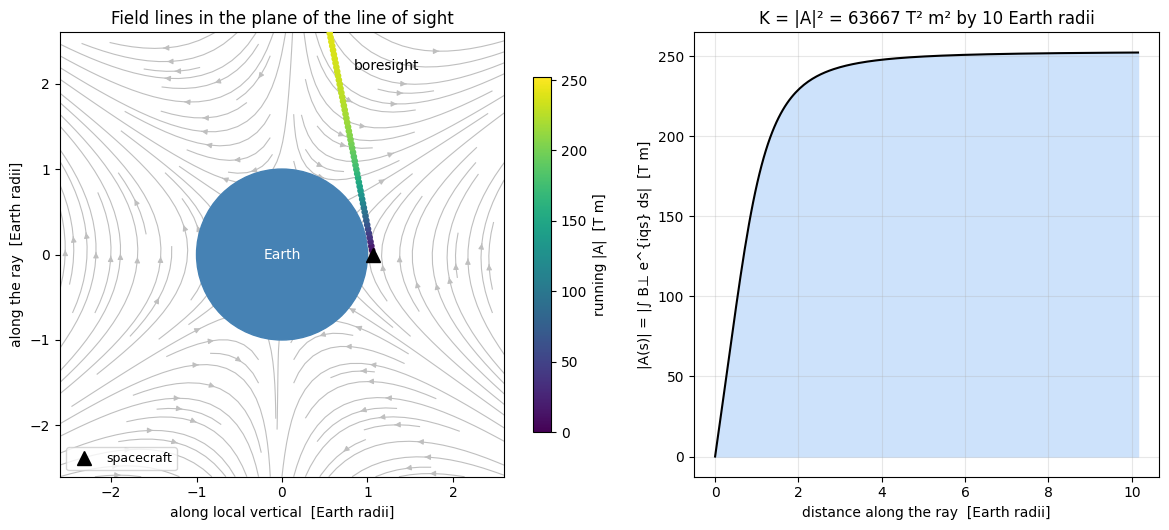

In [3]:
fig = cf.meridian_plane(r[k0], n[k0], time[k0], coeffs, LMAX)
plt.show()

## 2. What the aperture sees

The four apertures give a 20° full cone. $K$ is not constant across it — the
field geometry changes from one edge of the cone to the other, and the Earth
limb can cut through it. The state table therefore carries $K$ averaged over
the cone (`k_fov_t2m2`), not the boresight value. Same moment as figure 1.

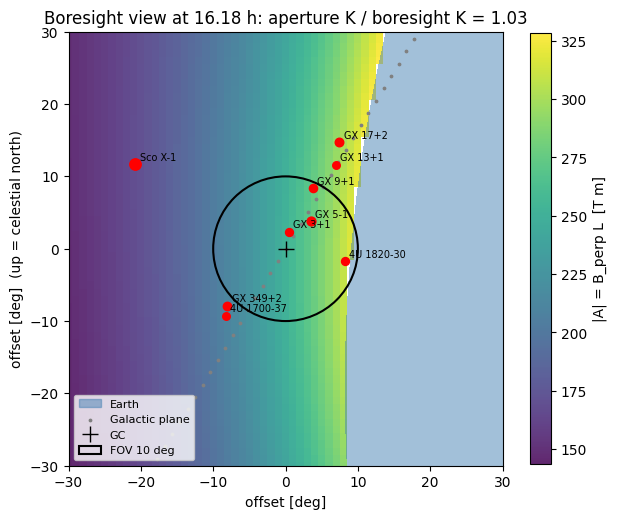

In [4]:
ax = fov_view(r[k0], time[k0], n[k0], coeffs, extent=30.0, lmax=LMAX)
ax.set_title(f"Boresight view at {t[k0] / 3600:.2f} h: aperture K / boresight K = "
             f"{table['k_fov_t2m2'][k0] / table['k_t2m2'][k0]:.2f}")
plt.show()

## 3. One orbit

Three orbits of the day. $K$ peaks once per orbit, where the boresight
grazes the limb; the particle-background proxy (cutoff rigidity) peaks at
the magnetic equator; both are set by where the spacecraft is in the field.
Science exposure (shaded) is umbra with the sky in view. Because $K$ and the
background proxy move together, a schedule has to *decorrelate* them, not
just maximise $K$.

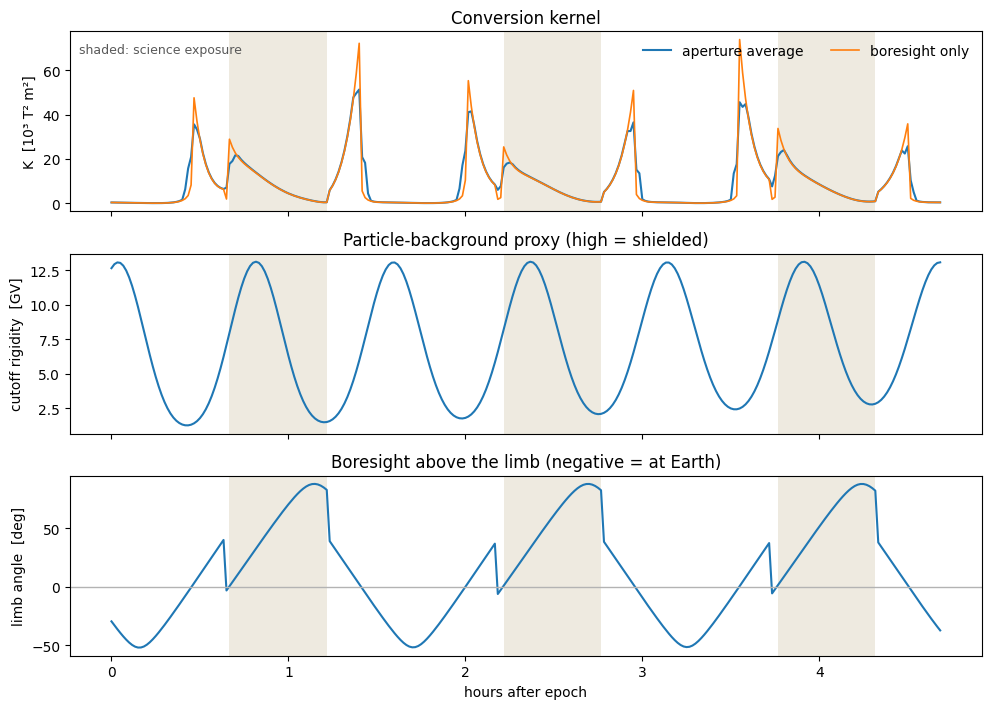

over the day's science exposure: corr(K, cutoff rigidity) = +0.77, corr(K, limb angle) = -0.87


In [5]:
fig = cf.orbit_strip(table, mode_index)
plt.show()
rho = np.corrcoef(table["k_fov_t2m2"][sci], table["cutoff_gv"][sci])[0, 1]
rho_limb = np.corrcoef(table["k_fov_t2m2"][sci], table["limb_deg"][sci])[0, 1]
print(f"over the day's science exposure: corr(K, cutoff rigidity) = {rho:+.2f}, corr(K, limb angle) = {rho_limb:+.2f}")

## 4. The ground track

Where the spacecraft is when each mode runs. Grey: sunlit, boresight
anti-Sun. Dark blue: in umbra but the Galactic Centre is behind the Earth.
Coloured: science exposure, coloured by aperture $K$. The shaded patch is
where the field is weakest at this altitude — the South Atlantic Anomaly,
where trapped particles reach the spacecraft and science normally stops
(ALP-MA-17, mask not yet applied).

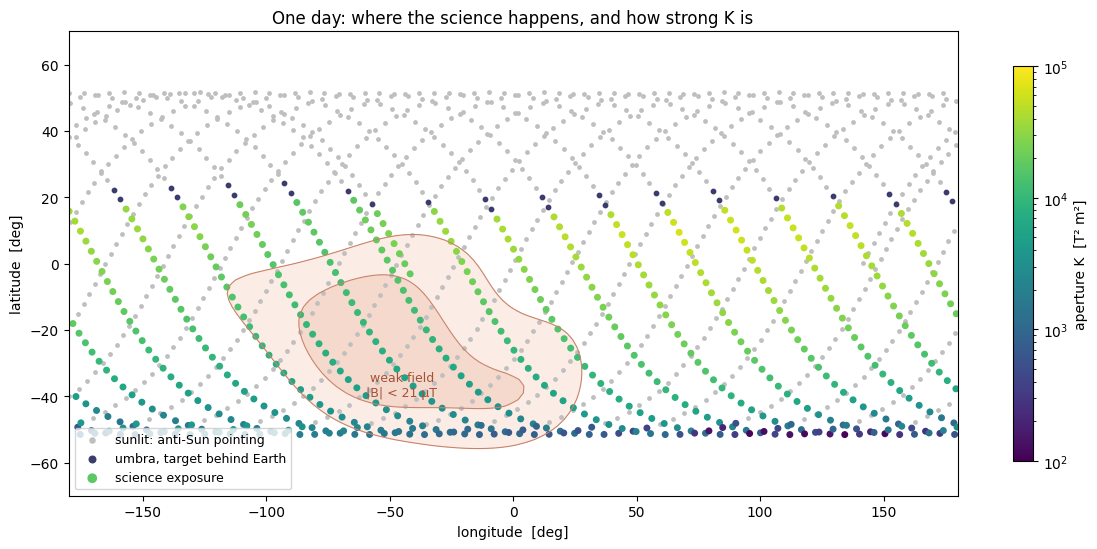

In [6]:
fig = cf.ground_track(table, coeffs, mode_index, ALT_KM)
plt.show()

## 5. Where to point

Every fixed inertial direction on the sky, each held for the whole day, at
5-minute cadence. Left: the isotropic continuum signal, $\sum\langle K\rangle
\Delta t$, relative to Galactic Centre pointing. Middle: the Milky Way line,
which also carries the halo column, $\sum\langle D\,K\rangle\Delta t$. Right:
how strongly $K$ tracks the background proxy for that pointing. The sky
splits into a half where the signal rises with the background and a half
where it falls — the ConOps lever.

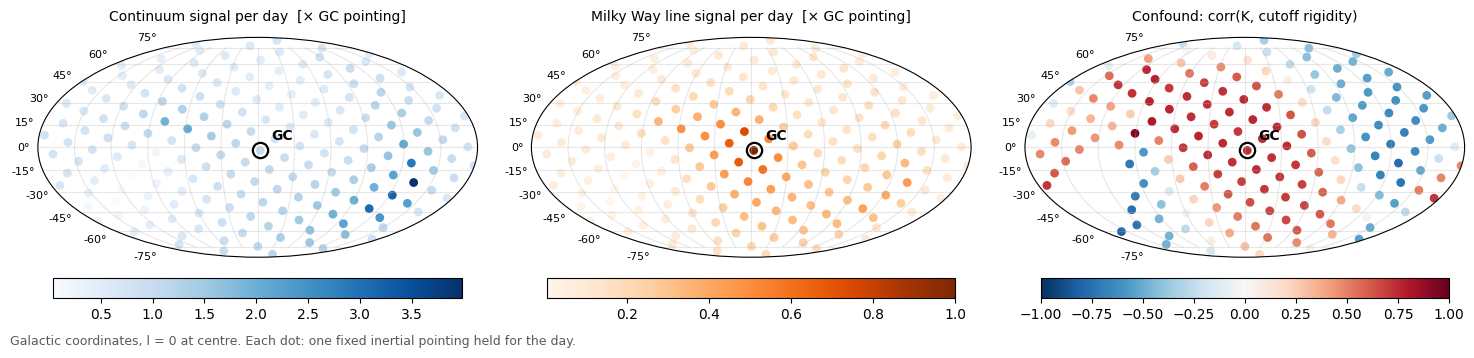

GC pointing: continuum rank 66/192, corr(K, Rc) = +0.74
best continuum direction: l = 225, b = -24: 4.0× GC, corr = -0.73, line signal 0.46× GC


In [7]:
step = int(300 / CADENCE_S)
scan = cf.sky_scan(time[::step], r[::step], coeffs, LMAX, n_dir=192)
fig, sky = cf.sky_maps(scan, table["umbra"][::step], table["cutoff_gv"][::step], 300.0)
plt.show()
gc = sky["gc"]
best = int(np.nanargmax(sky["rel_continuum"]))
rank = int(np.sum(sky["rel_continuum"] > 1.0)) + 1
print(f"GC pointing: continuum rank {rank}/{len(scan['l'])}, corr(K, Rc) = {sky['corr'][gc]:+.2f}")
print(f"best continuum direction: l = {scan['l'][best]:.0f}, b = {scan['b'][best]:.0f}: "
      f"{sky['rel_continuum'][best]:.1f}× GC, corr = {sky['corr'][best]:+.2f}, "
      f"line signal {sky['rel_line'][best]:.2f}× GC")

## 6. What it buys

The allowed-signal ceiling: the largest externally allowed benchmark
($g_{a\gamma\gamma}$ at the CAST bound, the invisible-decay rate at its
cosmological limit) folded through this schedule for the 187-day science
phase, one simulated day standing for all. Conversion uses Yamamoto's
normalisation, $P = 2.45\times10^{-21}\,(g/10^{-10}\,\mathrm{GeV^{-1}})^2\,K$.
The mass dependence comes from the phase-aware integral itself: $K$ depends
on $m_a$ only through $q = m_a^2/2E$.

187 days: Milky Way line 9.2e-03 counts, continuum 1.2e-03 counts


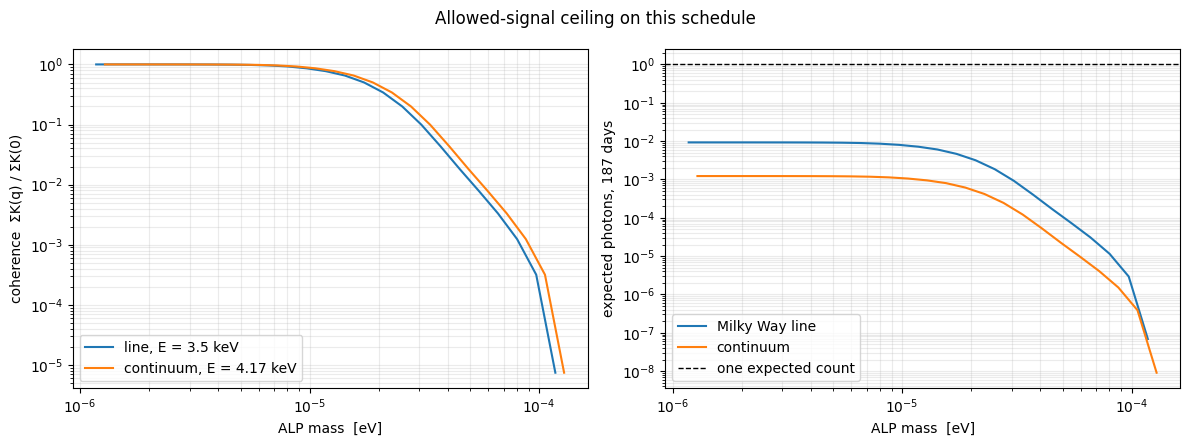

coherence halves at m = 1.7e-05 eV


In [8]:
G_GEV_INV, DECAY_RATE_GYR, PARENT_MASS_KEV = 5.8e-11, 6.3e-3, 7.0
AREA_CM2, THROUGHPUT, MISSION_DAYS = 12.0, 0.20, 187
Y_FLUX, Y_G, Y_TAU_S, Y_K, E_LO, E_HI = 1.6e-9, 3.3e-7, 4.32e17, 1.0e4, 2.0, 6.0
S_PER_GYR, ERG_PER_KEV, HBAR_C_EV_M = 3.15576e16, 1.602176634e-9, 1.973269804e-7

scale = CADENCE_S * MISSION_DAYS
grasp = AREA_CM2 * 2 * np.pi * (1 - np.cos(np.radians(10.0)))
p_per_k = 2.45e-21 * (G_GEV_INV / 1e-10) ** 2
rate_s = DECAY_RATE_GYR / S_PER_GYR
k_sum = table["k_fov_t2m2"][sci].sum() * scale
dk_sum = table["dk_fov_gevcm2_t2m2"][sci].sum() * scale
line_counts = 2 * rate_s / (4 * np.pi * PARENT_MASS_KEV * 1e-6) * p_per_k * dk_sum * grasp * THROUGHPUT
e_mean = 0.6 * (E_HI**2.5 - E_LO**2.5) / (E_HI**1.5 - E_LO**1.5)
cont_per_k = Y_FLUX / (e_mean * ERG_PER_KEV) * (G_GEV_INV / Y_G) ** 2 * rate_s * Y_TAU_S / Y_K
cont_counts = cont_per_k * k_sum * grasp * THROUGHPUT
print(f"{MISSION_DAYS} days: Milky Way line {line_counts:.1e} counts, continuum {cont_counts:.1e} counts")

q_grid = np.geomspace(1e-9, 1e-5, 25)
coh = cf.coherence_scan(r, n, time, coeffs, np.flatnonzero(sci)[::8], q_grid, LMAX)
mass = lambda e_kev: np.sqrt(2 * e_kev * 1e3 * HBAR_C_EV_M * q_grid)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].loglog(mass(PARENT_MASS_KEV / 2), coh, label=f"line, E = {PARENT_MASS_KEV / 2:g} keV")
ax[0].loglog(mass(e_mean), coh, label=f"continuum, E = {e_mean:.2f} keV")
ax[0].set_xlabel("ALP mass  [eV]"); ax[0].set_ylabel("coherence  ΣK(q) / ΣK(0)")
ax[1].loglog(mass(PARENT_MASS_KEV / 2), line_counts * coh, label="Milky Way line")
ax[1].loglog(mass(e_mean), cont_counts * coh, label="continuum")
ax[1].axhline(1, color="k", ls="--", lw=1, label="one expected count")
ax[1].set_xlabel("ALP mass  [eV]"); ax[1].set_ylabel(f"expected photons, {MISSION_DAYS} days")
for a in ax:
    a.grid(True, which="both", alpha=0.25); a.legend()
fig.suptitle("Allowed-signal ceiling on this schedule")
fig.tight_layout(); plt.show()
print(f"coherence halves at m = {np.interp(0.5, coh[::-1], mass(PARENT_MASS_KEV / 2)[::-1]):.1e} eV")

## Reading the pictures

- The signal is geometry: a line integral through the field, set by where
  the spacecraft is and where it looks. No sky target is required for the
  continuum; the Milky Way line adds the halo column on top.
- The aperture is wide enough that $K$ must be averaged over it; the
  boresight value can be off by tens of percent near the limb.
- The particle background follows the same geometry, so the raw size of
  $K$ is not the figure of merit — how *separable* its modulation is from
  the background's is (figures 3 and 5).
- Nominal Galactic Centre pointing is average for the continuum and sits in
  the high-confound half of the sky; better directions exist for the
  continuum, and they are poor for the line. The two channels want
  different ConOps.
- Even the largest allowed benchmark is far below one count for this
  schedule; the mission question is identifiability and method, not a
  coupling limit (charter, D18).